# Split Datasets Human

Split dataset to Train/Validation/Test sets

## A. Overview

To avoid Data Leakage, Train/Validation/Test set should contain different events.

Event type that have
- 03 events, can be in all set 
- ~~02 events, skip Validation set~~
- 01 event, can only in Train set

Random split to Train, Validation and Test sets:

- `event_type` with value **disaster** is exception, no specified defined event in the type.
- `event_name` with values **Landslides Worldwide**, **disaster_events** and **NaN** (from **eyewitness_messages** and **disasters_on_social_media** dataset)

## B. Load Dataset

In [1]:
from pathlib import Path
import csv

from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

df_humanitarian = pd.read_csv('../data/normalized/unified_humanitarian_dataset_normalized.csv')
df_humanitarian_bertweet = pd.read_csv('../data/normalized/unified_humanitarian_dataset_bertweet_normalized.csv')

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_32526/1078573441.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_humanitarian = pd.read_csv('../data/normalized/unified_humanitarian_dataset_normalized.csv')
/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_32526/1078573441.py:15: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_humanitarian_bertweet = pd.read_csv('../data/normalized/unified_humanitarian_dataset_bertweet_normalized.csv')


## C. Relevant

### C.1. Event types that has at least 03 events

Text(0.5, 1.0, 'Number of event_name entries for each event_type for humanitarian-labeled tweets')

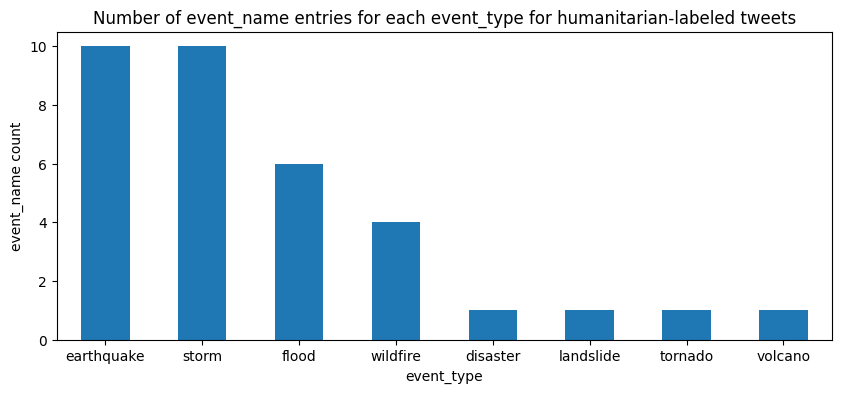

In [2]:
event_name_count_by_type = (
    df_humanitarian.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=0)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type for humanitarian-labeled tweets')

| event type | Train | Validation | Test | Note |
| --- | --- | --- | --- | --- |
| earthquake | ✅ | ✅ | ✅ | |
| storm | ✅ | ✅ | ✅ | |
| flood | ✅ | ✅ | ✅ | |
| wildfire | ✅ | ✅ | ✅ | |
| disaster | ✅ | ✅ | ✅ | unknow disaster, random split |
| landslide | ✅ | ✅ | ✅ | worldwide, random split |
| volcano | ✅ | 🚫 | 🚫 | |
| tornado | ✅ | 🚫 | 🚫 | |

In [3]:
counting = 0
gte_three_events = ['earthquake', 'storm', 'flood', 'wildfire']
for event_type in gte_three_events:
    count_by_event = df_humanitarian[df_humanitarian['event_type'] == event_type].groupby('event_name')['tweet_id'].count()
    print(f"Event type: {event_type}")
    print(count_by_event)
    print(count_by_event.sum())
    counting += count_by_event.sum()
    print('- - - - - -')

print(f"Total tweets: {counting}")

Event type: earthquake
event_name
2013 Pakistan Earthquake          1812
2014 California Earthquake        1795
2014 Chile Earthquake             2037
2015 Nepal Earthquake            12320
2016 Ecuador Earthquake           5660
2016 Italy Earthquake             1201
2016 Kaikoura Earthquake          1702
2017 Iraq-Iran Earthquake          413
2017 Puebla Mexico Earthquake     2990
2019 Pakistan Earthquake          1887
Name: tweet_id, dtype: int64
31817
- - - - - -
Event type: storm
event_name
2014 Hurricane Odile Mexico          1334
2014 Philippines Typhoon Hagupit    11043
2015 Cyclone Pam                     2442
2016 Hurricane Matthew               1618
2017 Hurricane Harvey               11453
2017 Hurricane Irma                 11299
2017 Hurricane Maria                 9790
2018 Hurricane Florence              4954
2019 Cyclone Idai                    3844
2019 Hurricane Dorian                6244
Name: tweet_id, dtype: int64
64021
- - - - - -
Event type: flood
event_name
2014

In [4]:
# manually picking the events each sets
df_humanitarian_validation_events = [
    '2014 California Earthquake',
    '2016 Kaikoura Earthquake',
    '2015 Cyclone Pam',
    '2018 Hurricane Florence',
    '2014 India Floods',
    '2017 California Wildfires',
]

df_humanitarian_test_events = [
    '2013 Pakistan Earthquake',
    '2016 Italy Earthquake',
    '2017 Iraq-Iran Earthquake',
    '2014 Hurricane Odile Mexico',
    '2016 Hurricane Matthew',
    '2019 Cyclone Idai',
    '2017 Sri Lanka Floods',
    '2018 Maryland Floods',
    '2018 Greece Wildfires',
]

df_humanitarian_train = df_humanitarian[
    ~df_humanitarian["event_name"].isin(df_humanitarian_validation_events + df_humanitarian_test_events)
    & df_humanitarian["event_type"].isin(gte_three_events)
]

df_humanitarian_validation = df_humanitarian[
    df_humanitarian["event_name"].isin(df_humanitarian_validation_events)
]

df_humanitarian_test = df_humanitarian[
    df_humanitarian["event_name"].isin(df_humanitarian_test_events)
]


In [5]:
print(len(df_humanitarian_train))
print(len(df_humanitarian_validation))
print(len(df_humanitarian_test))

95459
13785
13625


### C.2. Event types that has 01 events

`tornado`, and `volcano`

In [6]:
single_event_types = ['tornado', 'volcano']
print(len(df_humanitarian[df_humanitarian['event_type'].isin(single_event_types)]))
df_humanitarian_train = pd.concat([df_humanitarian_train,
    df_humanitarian[df_humanitarian['event_type'].isin(single_event_types)]
])
print(len(df_humanitarian_train)) # 150736 + 1571 = 152307

1113
96572


### C.4. Random split to Train, Validation and Test sets

- `event_type` with value **disaster** and **landslide**
- `event_name` with values **Landslides Worldwide**, **disaster_events** and **NaN**

In [7]:
undefined_mask = (
    df_humanitarian["event_type"].isin(["disaster", "landslide"])
    | df_humanitarian["event_name"].isna()
    | df_humanitarian["event_name"].isin(["Landslides Worldwide", "disaster_events"])
)

df_undefined_train, df_undefined_temp = train_test_split(
    df_humanitarian[undefined_mask],
    test_size=0.2,
    random_state=42,
    stratify=df_humanitarian[undefined_mask]["humanitarian_label"]
)
df_undefined_validation, df_undefined_test = train_test_split(
    df_undefined_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_undefined_temp[undefined_mask]["humanitarian_label"]
)
print(len(df_undefined_train))
print(len(df_undefined_validation))
print(len(df_undefined_test))

19861
2483
2483


/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_32526/2821445189.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stratify=df_undefined_temp[undefined_mask]["humanitarian_label"]


In [8]:
df_humanitarian_train = pd.concat(
    [df_humanitarian_train, df_undefined_train]
)

df_humanitarian_validation = pd.concat(
    [df_humanitarian_validation, df_undefined_validation]
)

df_humanitarian_test = pd.concat(
    [df_humanitarian_test, df_undefined_test]
)

In [9]:
print(len(df_humanitarian_train)) # 152307 + 39846 = 192153
print(len(df_humanitarian_validation))  # 17382 + 8539 = 26376
print(len(df_humanitarian_test))  # 17382 + 8539 = 25921

# ration between train, validation, and test sets
total = len(df_humanitarian_train) + len(df_humanitarian_validation) + len(df_humanitarian_test)
print(f"Train: {len(df_humanitarian_train) / total:.2%}")
print(f"Validation: {len(df_humanitarian_validation) / total:.2%}")
print(f"Test: {len(df_humanitarian_test) / total:.2%}")

116433
16268
16108
Train: 78.24%
Validation: 10.93%
Test: 10.82%


### C.5. Check class ration

In [10]:
df_humanitarian_train.to_csv('../data/splited/humanitarian_normalized_train.csv', index=False, quoting=csv.QUOTE_ALL)
df_humanitarian_validation.to_csv('../data/splited/humanitarian_normalized_validation.csv', index=False, quoting=csv.QUOTE_ALL)
df_humanitarian_test.to_csv('../data/splited/humanitarian_normalized_test.csv', index=False, quoting=csv.QUOTE_ALL)

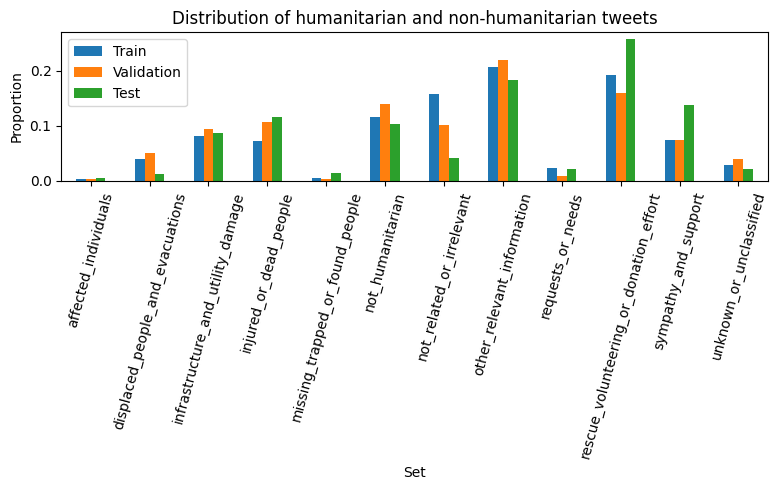

In [11]:
class_dist = pd.DataFrame({
    "Train": df_humanitarian_train["humanitarian_label"].value_counts(normalize=True).sort_index(),
    "Validation": df_humanitarian_validation["humanitarian_label"].value_counts(normalize=True).sort_index(),
    "Test": df_humanitarian_test["humanitarian_label"].value_counts(normalize=True).sort_index(),
}).fillna(0)

ax = class_dist.plot(kind="bar", figsize=(8, 5), rot=75)
ax.set_xlabel("Set")
ax.set_ylabel("Proportion")
ax.set_title("Distribution of humanitarian and non-humanitarian tweets")
plt.tight_layout()
plt.show()

### C.6. Split BERTweet sets

In [12]:
# Read the BERTweet-normalized dataset
df_humanitarian_bertweet = pd.read_csv(
    "../data/normalized/unified_humanitarian_dataset_bertweet_normalized.csv"
)

# Save the BERTweet-normalized datasets for train, validation, and test sets
# Shuffle the rows before saving to CSV.
df_humanitarian_bertweet[df_humanitarian_bertweet["tweet_id"].isin(df_humanitarian_train["tweet_id"])][
    ["tweet_text", "humanitarian_label"]
].sample(frac=1, random_state=42).to_csv(
    "../data/splited/humanitarian_bertweet_normalized_train.csv",
    index=False,
    quoting=csv.QUOTE_ALL,
)

df_humanitarian_bertweet[df_humanitarian_bertweet["tweet_id"].isin(df_humanitarian_validation["tweet_id"])][
    ["tweet_text", "humanitarian_label"]
].sample(frac=1, random_state=42).to_csv(
    "../data/splited/humanitarian_bertweet_normalized_validation.csv",
    index=False,
    quoting=csv.QUOTE_ALL,
)

df_humanitarian_bertweet[df_humanitarian_bertweet["tweet_id"].isin(df_humanitarian_test["tweet_id"])][
    ["tweet_text", "humanitarian_label"]
].sample(frac=1, random_state=42).to_csv(
    "../data/splited/humanitarian_bertweet_normalized_test.csv",
    index=False,
    quoting=csv.QUOTE_ALL,
)

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_32526/1777657320.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_humanitarian_bertweet = pd.read_csv(
